In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np



#### k-Nearest Neighbors (Le plus proche k voisins)
##### k-Neighbors classification

Rappelons que dans la classification, les étiquettes sont des valeurs discrètes.

Nous générons des données pour expliquer la méthode knn.

Il y a deux classes: triangle rouge: classe 1; round blue: classe 2.

On  va classer les étoiles.

On trouve les k plus proches voisins. On classe l'étoile  avec la majorités de ces voisins. 


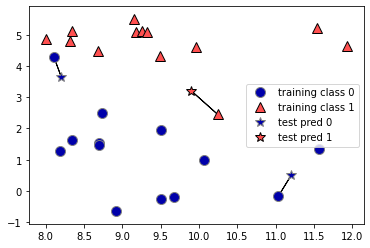

In [2]:
from IPython.display import Image
Image("knn_1.png")

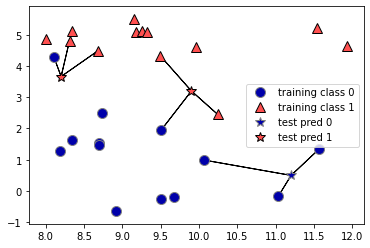

In [3]:
Image("knn_3.png")

Nous pouvons constater que k=1  et k=3 ne donnent pas la même classification.

In [4]:
from sklearn.datasets import make_blobs

from sklearn.model_selection import train_test_split

#X,y = make_forge()
X, y = make_blobs(centers=2, random_state=5, n_samples=60)


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=96, shuffle=True)

In [5]:
print(" taille de l'ensemble d'apprentissage {}: de l'ensemble de test {}:".format(X_train.shape, X_test.shape))

 taille de l'ensemble d'apprentissage (45, 2): de l'ensemble de test (15, 2):


<function matplotlib.pyplot.show(close=None, block=None)>

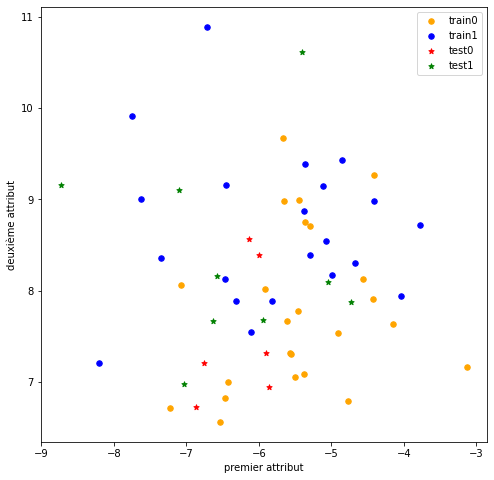

In [6]:
plt.figure(figsize=(8, 8))
#on affiche données train classe 0 orange
plt.scatter(
    X_train[y_train == 0, 0], X_train[y_train == 0, 1],
    s=30, c='orange',
    marker='o',
    label='trainclasse=0'
)
#on affiche données train classe 1 blue
plt.scatter(
    X_train[y_train == 1, 0], X_train[y_train == 1, 1],
    s=30, c='blue',
    marker='o',
    label='trainclasse=1'
)

#on affiche données test classe 0 red
plt.scatter(
    X_test[y_test == 0, 0], X_test[y_test == 0, 1],
    s=30, c='red',
    marker='*',
    label='testclasse=0'
)
#on affiche données test classe 1 green
plt.scatter(
    X_test[y_test == 1, 0], X_test[y_test == 1, 1],
    s=30, c='green',
    marker='*',
    label='testclasse=1'
)

#plt.scatter(X_train[:, 0], X_train[:, 1],marker='+', c=y_train)
#plt.scatter(X_test[:, 0], X_test[:, 1], linewidth=5.0, marker= '*',c=y_test)

plt.xlabel("premier attribut")
plt.ylabel("deuxième attribut")
plt.legend(["train0","train1","test0","test1" ])
plt.show

On applique la méthode  KNN avec le nombre de voisins= 1

In [7]:
from sklearn.neighbors import KNeighborsClassifier
model1 = KNeighborsClassifier(n_neighbors=1)

In [8]:
model1.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [9]:

y_predict=model1.predict(X_test)

print("predictions:", y_predict)

print("exact:      ", y_test)

predictions: [0 1 1 0 0 1 1 0 0 0 1 0 1 1 1]
exact:       [1 1 1 0 1 0 1 1 0 0 1 0 1 0 1]


In [10]:
print("Test set accuracy: {}".format(model1.score(X_test, y_test)))

Test set accuracy: 0.6666666666666666


<function matplotlib.pyplot.show(close=None, block=None)>

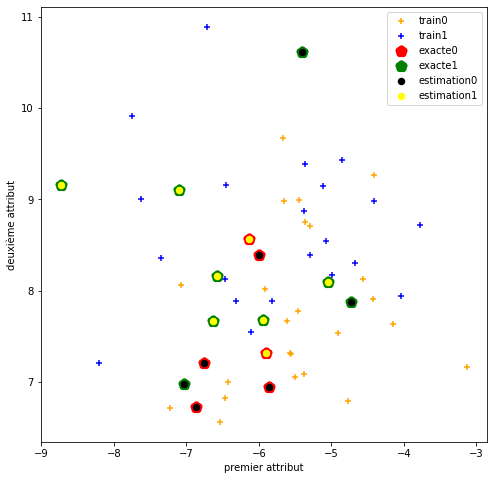

In [11]:
plt.figure(figsize=(8, 8))
#on affiche données train classe 0 orange
plt.scatter(
   X_train[y_train == 0, 0], X_train[y_train == 0, 1],
    s=30, c='orange',
   marker='+',
    label='trainclasse=0'
)
#on affiche données train classe 1 blue
plt.scatter(
    X_train[y_train == 1, 0], X_train[y_train == 1, 1],
    s=30, c='blue',
    marker='+',
    label='trainclasse=1'
)

#on affiche données test classe 0 red
plt.scatter(
    X_test[y_test == 0, 0], X_test[y_test == 0, 1],
    s=30, c='red',
    marker='*',
    linewidth=7.0,
    label='testclasse=0'
)
#on affiche données test classe 1 green
plt.scatter(
    X_test[y_test == 1, 0], X_test[y_test == 1, 1],
    s=30, c='green',
    marker='*',
    linewidth=7.0,
    label='testclasse=1'
)

#on affiche données test classe 0 red
plt.scatter(
    X_test[(y_predict == 0) , 0], X_test[y_predict == 0 , 1],
    s=30, c='black',
    marker='o',
    linewidth=2.0,
    label='predictclasse=0'
)
#on affiche données test classe 1 green

plt.scatter(
    X_test[y_predict == 1, 0], X_test[y_predict == 1, 1],
    s=30, c='yellow',
    marker='o',
    linewidth=2.0,
    label='predictclasse=1'
)

#plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
#plt.scatter(X_test[:, 0], X_test[:, 1],  marker= 'o',linewidth=5.0,c=y_predict)
#plt.scatter(X_test[:, 0], X_test[:, 1],  marker= '*',c=y_test)

plt.xlabel("premier attribut")
plt.ylabel("deuxième attribut")
plt.legend(['train0', 'train1','exacte0', 'exacte1', "estimation0", "estimation1"])
plt.show

Les points red + black sont des estimations correctes pour classe0;
Les points green+yellow sont des estimations correctes pour classe 1;
Combien des points ne sont pas estimés correctement?


Estimer la classe de la donnéé avec premier attribut=12 et 2ème attribut=5

In [12]:
print(model1.predict([[-5,9]]))

[1]


In [13]:
print(model1.predict([[-4,8]]))

[1]


In [14]:
model3 = KNeighborsClassifier(n_neighbors=3)
model3.fit(X_train, y_train)
y_predict=model3.predict(X_test)
print("predictions k=3:", y_predict)

print("exacte:         ", y_test)
print("Test set accuracy: {}".format(model3.score(X_test, y_test)))

predictions k=3: [0 1 1 0 0 0 1 1 0 1 1 0 1 0 1]
exacte:          [1 1 1 0 1 0 1 1 0 0 1 0 1 0 1]
Test set accuracy: 0.8


<function matplotlib.pyplot.show(close=None, block=None)>

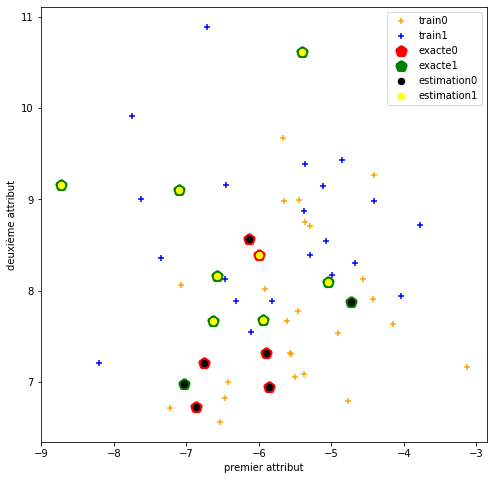

In [15]:
plt.figure(figsize=(8, 8))
#on affiche données train classe 0 orange
plt.scatter(
   X_train[y_train == 0, 0], X_train[y_train == 0, 1],
    s=30, c='orange',
   marker='+',
    label='trainclasse=0'
)
#on affiche données train classe 1 blue
plt.scatter(
    X_train[y_train == 1, 0], X_train[y_train == 1, 1],
    s=30, c='blue',
    marker='+',
    label='trainclasse=1'
)

#on affiche données test classe 0 red
plt.scatter(
    X_test[y_test == 0, 0], X_test[y_test == 0, 1],
    s=30, c='red',
    marker='*',
    linewidth=7.0,
    label='testclasse=0'
)
#on affiche données test classe 1 green
plt.scatter(
    X_test[y_test == 1, 0], X_test[y_test == 1, 1],
    s=30, c='green',
    marker='*',
    linewidth=7.0,
    label='testclasse=1'
)

#on affiche données test classe 0 red
plt.scatter(
    X_test[(y_predict == 0) , 0], X_test[y_predict == 0 , 1],
    s=30, c='black',
    marker='o',
    linewidth=2.0,
    label='predictclasse=0'
)
#on affiche données test classe 1 green

plt.scatter(
    X_test[y_predict == 1, 0], X_test[y_predict == 1, 1],
    s=30, c='yellow',
    marker='o',
    linewidth=2.0,
    label='predictclasse=1'
)

#plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
#plt.scatter(X_test[:, 0], X_test[:, 1],  marker= 'o',linewidth=5.0,c=y_predict)
#plt.scatter(X_test[:, 0], X_test[:, 1],  marker= '*',c=y_test)

plt.xlabel("premier attribut")
plt.ylabel("deuxième attribut")
plt.legend(['train0', 'train1','exacte0', 'exacte1', "estimation0", "estimation1"])
plt.show

Combien des points ne sont pas estimés correctement?

Que peut-on dire pour les qualités des méthodes k=1 et k=3 pour ce jeu de données? 

In [16]:
print(model3.predict([[-5,9]]))

[1]


In [17]:
print(model3.predict([[-4,8]]))

[0]


In [18]:
model5 = KNeighborsClassifier(n_neighbors=5)
model5.fit(X_train, y_train)
y_predict=model5.predict(X_test)
print("predictions k=5:", y_predict)

print("exacte:         ", y_test)
print("Test set accuracy: {}".format(model5.score(X_test, y_test)))

predictions k=5: [0 1 1 0 0 1 1 1 0 1 1 0 1 0 1]
exacte:          [1 1 1 0 1 0 1 1 0 0 1 0 1 0 1]
Test set accuracy: 0.7333333333333333


<function matplotlib.pyplot.show(close=None, block=None)>

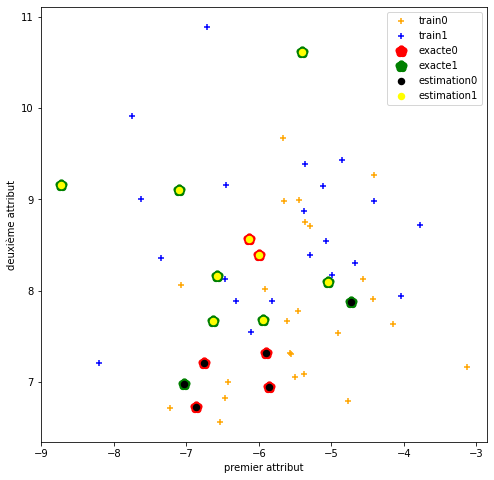

In [19]:
plt.figure(figsize=(8, 8))
#on affiche données train classe 0 orange
plt.scatter(
   X_train[y_train == 0, 0], X_train[y_train == 0, 1],
    s=30, c='orange',
   marker='+',
    label='trainclasse=0'
)
#on affiche données train classe 1 blue
plt.scatter(
    X_train[y_train == 1, 0], X_train[y_train == 1, 1],
    s=30, c='blue',
    marker='+',
    label='trainclasse=1'
)

#on affiche données test classe 0 red
plt.scatter(
    X_test[y_test == 0, 0], X_test[y_test == 0, 1],
    s=30, c='red',
    marker='*',
    linewidth=7.0,
    label='testclasse=0'
)
#on affiche données test classe 1 green
plt.scatter(
    X_test[y_test == 1, 0], X_test[y_test == 1, 1],
    s=30, c='green',
    marker='*',
    linewidth=7.0,
    label='testclasse=1'
)

#on affiche données test classe 0 red
plt.scatter(
    X_test[(y_predict == 0) , 0], X_test[y_predict == 0 , 1],
    s=30, c='black',
    marker='o',
    linewidth=2.0,
    label='predictclasse=0'
)
#on affiche données test classe 1 green

plt.scatter(
    X_test[y_predict == 1, 0], X_test[y_predict == 1, 1],
    s=30, c='yellow',
    marker='o',
    linewidth=2.0,
    label='predictclasse=1'
)

#plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
#plt.scatter(X_test[:, 0], X_test[:, 1],  marker= 'o',linewidth=5.0,c=y_predict)
#plt.scatter(X_test[:, 0], X_test[:, 1],  marker= '*',c=y_test)

plt.xlabel("premier attribut")
plt.ylabel("deuxième attribut")
plt.legend(['train0', 'train1','exacte0', 'exacte1', "estimation0", "estimation1"])
plt.show

In [20]:
print(model5.predict([[-5,9]]))

[0]


In [21]:
print(model5.predict([[-4,8]]))

[0]


Combien des points ne sont pas estimés correctement?

Que peut-on dire pour les qualités des méthodes k=1, k=3 et k=5 pour ce jeu de données? 

**Cross-Validation**

Choisir le meilleur modèle.


https://scikit-learn.org/stable/modules/cross_validation.html

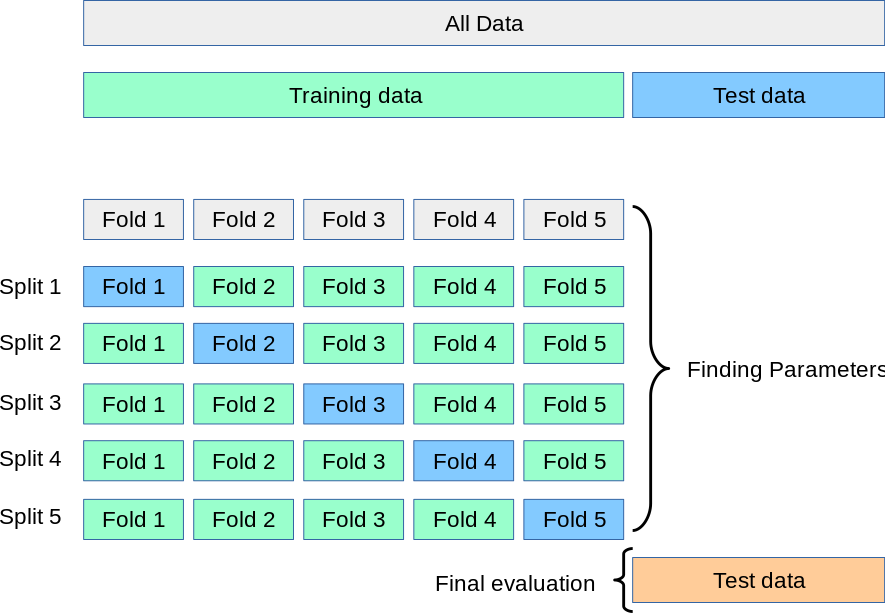

In [25]:
Image("grid_search_cross_validation.png")

In [29]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(KNeighborsClassifier(1), X_train, y_train, cv=5,scoring="accuracy")
print("scores:",scores)

print("valeur moyenne:", scores.mean())

#cross_val_score(KNeighborsClassifier(1), X_train, y_train, cv=5,scoring="accuracy").mean()

scores: [0.44444444 0.77777778 0.66666667 0.77777778 0.55555556]
valeur moyenne: 0.6444444444444445


[0.6444444444444445, 0.6444444444444445, 0.7333333333333334, 0.6444444444444445, 0.6444444444444445, 0.5777777777777777, 0.6222222222222221, 0.6, 0.6222222222222223]


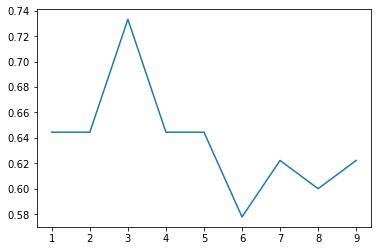

In [40]:
val_score=[]
for k in range(1,10):
    score=cross_val_score(KNeighborsClassifier(k), X_train, y_train, cv=5,scoring="accuracy").mean()
    val_score.append(score)
x=np.arange(1,10)
print(val_score)
plt.plot(x,val_score)

In [42]:
print("3",model3.score(X_test, y_test))

0.8


In [43]:
print("1",model1.score(X_test, y_test))

1 0.6666666666666666


In [44]:
print("5",model5.score(X_test, y_test))

5 0.7333333333333333


In [46]:
#On choisit nombre de voisins=3
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, model3.predict(X_test))

#Diagonal: nombre de bonne estimations

array([[5, 1],
       [2, 7]])